# Energy Forecast PT - Model Training

Treinamento de modelos de Machine Learning para previsão de consumo energético.

**Modelos:**
- Random Forest
- XGBoost
- LightGBM
- CatBoost

## 1. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
import json
from datetime import datetime

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from src.features.feature_engineering import FeatureEngineer
from src.models.evaluation import ModelEvaluator

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("Bibliotecas carregadas")
print(f"Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Bibliotecas carregadas
Inicio: 2025-10-07 10:26:14


## 2. Carregar Dados

In [2]:
# Carregar dados processados
df = pd.read_parquet('../data/processed/processed_data.parquet')
print(f"Dados carregados: {len(df):,} linhas")
print(f"Periodo: {df['timestamp'].min()} a {df['timestamp'].max()}")
print(f"Regioes: {df['region'].unique()}")
print(f"Consumo - Min: {df['consumption_mw'].min():.2f} MW, Max: {df['consumption_mw'].max():.2f} MW")

Dados carregados: 175,205 linhas
Periodo: 2021-01-01 00:00:00 a 2024-12-31 00:00:00
Regioes: ['Alentejo' 'Algarve' 'Centro' 'Lisboa' 'Norte']
Consumo - Min: 150.00 MW, Max: 4036.51 MW


## 3. Feature Engineering

In [3]:
# Feature engineering
fe = FeatureEngineer()
df_features = fe.create_all_features(df)

print(f"\nDados apos feature engineering: {len(df_features):,} linhas")
print(f"Total de features: {df_features.shape[1]} colunas")
print(f"Retencao de dados: {len(df_features)/len(df)*100:.1f}%")

Creating features...
  - Temporal features
  - Lag features
  - Rolling features
  - Interaction features
  - Removed 240 rows with NaN

Dados apos feature engineering: 174,965 linhas
Total de features: 73 colunas
Retencao de dados: 99.9%


## 4. Preparar Features e Target

In [4]:
# Excluir colunas nao numericas e target
exclude_cols = ['timestamp', 'consumption_mw', 'region', 'holiday_name']

# Adicionar colunas datetime que podem ter sido criadas
for col in df_features.columns:
    if col in exclude_cols:
        continue
    if pd.api.types.is_datetime64_any_dtype(df_features[col]):
        exclude_cols.append(col)
    if df_features[col].dtype == 'object':
        exclude_cols.append(col)

# Features finais
features = [c for c in df_features.columns if c not in exclude_cols]
target = 'consumption_mw'

print(f"Features selecionadas: {len(features)}")
print(f"Target: {target}")
print(f"\nPrimeiras 10 features: {features[:10]}")

Features selecionadas: 67
Target: consumption_mw

Primeiras 10 features: ['latitude', 'longitude', 'temperature', 'temperature_feels_like', 'humidity', 'wind_speed', 'precipitation', 'cloud_cover', 'pressure', 'is_holiday']


## 5. Split Temporal (70% Train / 15% Val / 15% Test)

In [5]:
# Ordenar por timestamp
df_features = df_features.sort_values('timestamp').reset_index(drop=True)

# Split temporal 70/15/15
n = len(df_features)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train = df_features.iloc[:train_end]
val = df_features.iloc[train_end:val_end]
test = df_features.iloc[val_end:]

# Extrair X e y
X_train = train[features].values
y_train = train[target].values

X_val = val[features].values
y_val = val[target].values

X_test = test[features].values
y_test = test[target].values

# Guardar timestamps e regioes para analise posterior
timestamps_test = test['timestamp'].reset_index(drop=True)
regions_test = test['region'].reset_index(drop=True)

print("="*70)
print("SPLIT TEMPORAL")
print("="*70)
print(f"Train: {len(X_train):,} amostras ({len(X_train)/n*100:.1f}%)")
print(f"Val:   {len(X_val):,} amostras ({len(X_val)/n*100:.1f}%)")
print(f"Test:  {len(X_test):,} amostras ({len(X_test)/n*100:.1f}%)")
print("="*70)
print(f"\nPeriodo Train: {train['timestamp'].min()} a {train['timestamp'].max()}")
print(f"Periodo Val:   {val['timestamp'].min()} a {val['timestamp'].max()}")
print(f"Periodo Test:  {test['timestamp'].min()} a {test['timestamp'].max()}")

SPLIT TEMPORAL
Train: 122,475 amostras (70.0%)
Val:   26,245 amostras (15.0%)
Test:  26,245 amostras (15.0%)

Periodo Train: 2021-01-03 00:00:00 a 2023-10-20 14:00:00
Periodo Val:   2023-10-20 15:00:00 a 2024-05-26 07:00:00
Periodo Test:  2024-05-26 08:00:00 a 2024-12-31 00:00:00


## 6. Treinar Modelos

In [6]:
# Inicializar avaliador
evaluator = ModelEvaluator(output_dir='../data/models')

# Dicionarios para armazenar modelos e resultados
models = {}
results = []

print("\nIniciando treinamento dos modelos...")
print("="*70)


Iniciando treinamento dos modelos...


### 6.1 Random Forest

In [7]:
print("\n[1/4] Treinando Random Forest...")

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf.fit(X_train, y_train)

# Validacao
y_val_pred = rf.predict(X_val)
metrics = evaluator.calculate_metrics(y_val, y_val_pred, prefix='val_')

print(f"  Val - MAE: {metrics['val_mae']:.2f} MW | RMSE: {metrics['val_rmse']:.2f} MW | R2: {metrics['val_r2']:.4f}")

models['random_forest'] = rf
results.append({'model': 'Random Forest', **metrics})


[1/4] Treinando Random Forest...
  Val - MAE: 8.76 MW | RMSE: 21.55 MW | R2: 0.9993


### 6.2 XGBoost

In [8]:
print("\n[2/4] Treinando XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Validacao
y_val_pred = xgb_model.predict(X_val)
metrics = evaluator.calculate_metrics(y_val, y_val_pred, prefix='val_')

print(f"  Val - MAE: {metrics['val_mae']:.2f} MW | RMSE: {metrics['val_rmse']:.2f} MW | R2: {metrics['val_r2']:.4f}")

models['xgboost'] = xgb_model
results.append({'model': 'XGBoost', **metrics})


[2/4] Treinando XGBoost...
  Val - MAE: 10.16 MW | RMSE: 19.00 MW | R2: 0.9995


### 6.3 LightGBM

In [9]:
print("\n[3/4] Treinando LightGBM...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Validacao
y_val_pred = lgb_model.predict(X_val)
metrics = evaluator.calculate_metrics(y_val, y_val_pred, prefix='val_')

print(f"  Val - MAE: {metrics['val_mae']:.2f} MW | RMSE: {metrics['val_rmse']:.2f} MW | R2: {metrics['val_r2']:.4f}")

models['lightgbm'] = lgb_model
results.append({'model': 'LightGBM', **metrics})


[3/4] Treinando LightGBM...
  Val - MAE: 14.53 MW | RMSE: 24.29 MW | R2: 0.9992


### 6.4 CatBoost

In [10]:
print("\n[4/4] Treinando CatBoost...")

cat_model = CatBoostRegressor(
    iterations=500,
    depth=10,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_state=42,
    verbose=False
)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False
)

# Validacao
y_val_pred = cat_model.predict(X_val)
metrics = evaluator.calculate_metrics(y_val, y_val_pred, prefix='val_')

print(f"  Val - MAE: {metrics['val_mae']:.2f} MW | RMSE: {metrics['val_rmse']:.2f} MW | R2: {metrics['val_r2']:.4f}")

models['catboost'] = cat_model
results.append({'model': 'CatBoost', **metrics})

print("\n" + "="*70)
print("Todos os modelos treinados!")
print("="*70)


[4/4] Treinando CatBoost...
  Val - MAE: 21.46 MW | RMSE: 32.49 MW | R2: 0.9985

Todos os modelos treinados!


## 7. Comparar Modelos

In [11]:
# Criar DataFrame com resultados
df_results = pd.DataFrame(results).sort_values('val_rmse')

print("\n" + "="*90)
print("COMPARACAO DE MODELOS - VALIDACAO")
print("="*90)
print(df_results[['model', 'val_mae', 'val_rmse', 'val_mape', 'val_r2']].to_string(index=False))
print("="*90)

# Identificar melhor modelo
best_name = df_results.iloc[0]['model']
best_metrics = df_results.iloc[0]

print(f"\n🏆 MELHOR MODELO: {best_name}")
print(f"   MAE:  {best_metrics['val_mae']:.2f} MW")
print(f"   RMSE: {best_metrics['val_rmse']:.2f} MW")
print(f"   MAPE: {best_metrics['val_mape']:.2f}%")
print(f"   R²:   {best_metrics['val_r2']:.4f}")


COMPARACAO DE MODELOS - VALIDACAO
        model   val_mae  val_rmse  val_mape   val_r2
      XGBoost 10.160301 18.998196  0.881183 0.999490
Random Forest  8.762519 21.552800  0.737650 0.999343
     LightGBM 14.525804 24.294704  1.309578 0.999166
     CatBoost 21.460710 32.486148  2.029198 0.998508

🏆 MELHOR MODELO: XGBoost
   MAE:  10.16 MW
   RMSE: 19.00 MW
   MAPE: 0.88%
   R²:   0.9995


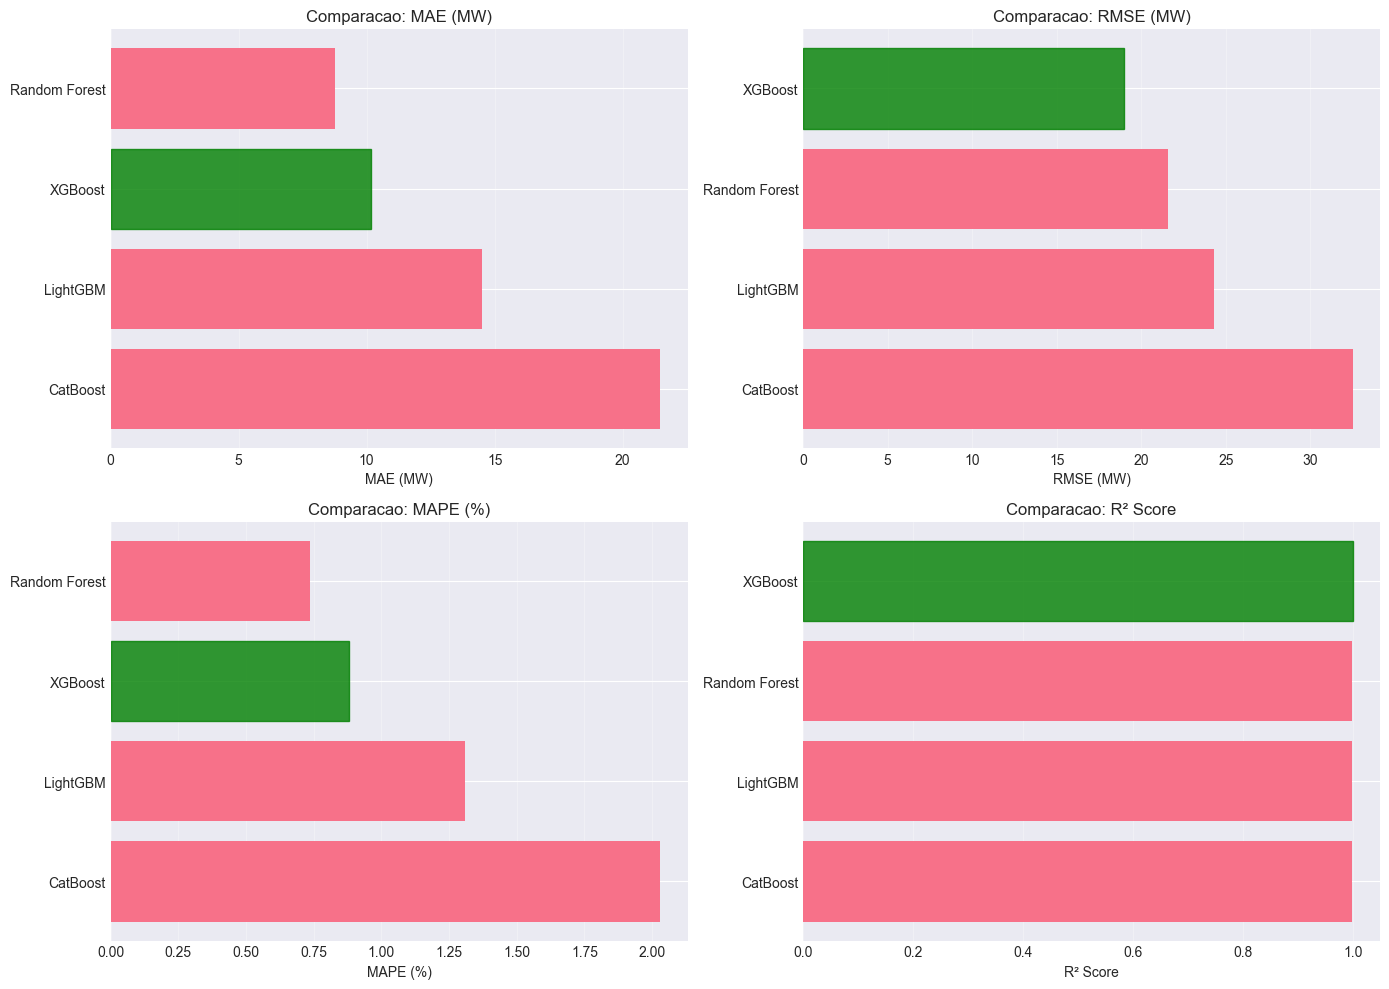

✓ Grafico salvo: data/models/model_comparison.png


In [12]:
# Visualizar comparacao
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = [
    ('val_mae', 'MAE (MW)', False),
    ('val_rmse', 'RMSE (MW)', False),
    ('val_mape', 'MAPE (%)', False),
    ('val_r2', 'R² Score', True)
]

for idx, (metric, label, ascending) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    data = df_results.sort_values(metric, ascending=ascending)
    
    bars = ax.barh(data['model'], data[metric])
    
    # Destacar melhor modelo
    best_idx = data['model'].tolist().index(best_name)
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(0.8)
    
    ax.set_xlabel(label)
    ax.set_title(f'Comparacao: {label}')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../data/models/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico salvo: data/models/model_comparison.png")

## 8. Avaliar no Conjunto de Teste

In [13]:
# Selecionar melhor modelo
best_key = best_name.lower().replace(' ', '_')
best_model = models[best_key]

print(f"\nAvaliando {best_name} no conjunto de teste...")

# Predicao no teste
y_test_pred = best_model.predict(X_test)

# Calcular metricas de teste
test_metrics = evaluator.calculate_metrics(y_test, y_test_pred, prefix='test_')

print("\n" + "="*70)
print(f"RESULTADOS NO TESTE - {best_name}")
print("="*70)
print(f"MAE:   {test_metrics['test_mae']:.2f} MW")
print(f"RMSE:  {test_metrics['test_rmse']:.2f} MW")
print(f"MAPE:  {test_metrics['test_mape']:.2f}%")
print(f"R²:    {test_metrics['test_r2']:.4f}")
print(f"NRMSE: {test_metrics['test_nrmse']:.4f}")
print("="*70)


Avaliando XGBoost no conjunto de teste...

RESULTADOS NO TESTE - XGBoost
MAE:   10.65 MW
RMSE:  20.25 MW
MAPE:  0.86%
R²:    0.9995
NRMSE: 0.0148


Plot saved to ..\data\models\xgboost_test_predictions.png


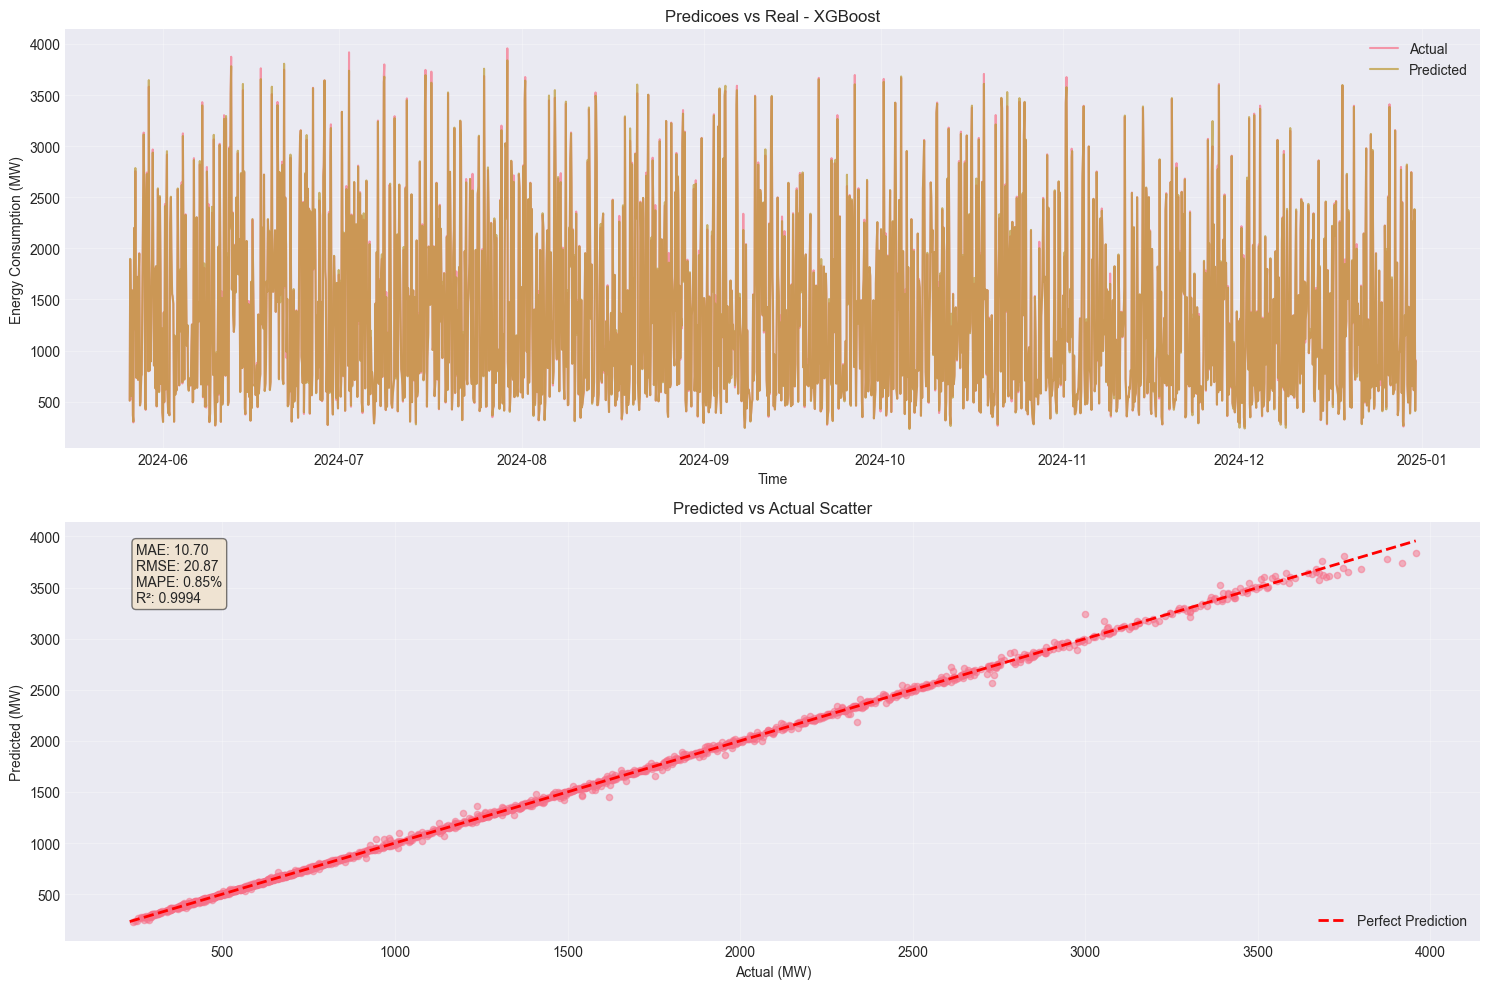

✓ Grafico salvo: data/models/xgboost_test_predictions.png


In [14]:
# Plot predicoes vs real
evaluator.plot_predictions(
    y_test,
    y_test_pred,
    timestamps_test.values,
    title=f'Predicoes vs Real - {best_name}',
    save_name=f'{best_key}_test_predictions.png',
    max_points=2000
)
plt.show()

print(f"✓ Grafico salvo: data/models/{best_key}_test_predictions.png")

## 9. Salvar Modelos e Metadados

In [15]:
# Criar diretorio de output
output_dir = Path('../data/models')
output_dir.mkdir(parents=True, exist_ok=True)

print("\nSalvando modelos e resultados...")
print("="*70)

# Salvar todos os modelos
for name, model in models.items():
    model_path = output_dir / f'{name}.pkl'
    joblib.dump(model, model_path)
    print(f"✓ {name}.pkl")

# Salvar melhor modelo separadamente
best_model_path = output_dir / f'{best_key}_best.pkl'
joblib.dump(best_model, best_model_path)
print(f"\n✓ Melhor modelo: {best_key}_best.pkl")

# Salvar feature names
with open(output_dir / 'feature_names.txt', 'w') as f:
    for feature in features:
        f.write(f"{feature}\n")
print(f"✓ feature_names.txt ({len(features)} features)")

# Salvar comparacao de modelos
df_results.to_csv(output_dir / 'model_comparison.csv', index=False)
print(f"✓ model_comparison.csv")

# Salvar metadata do treinamento
metadata = {
    'best_model': best_name,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_info': {
        'total_samples': int(len(df_features)),
        'train_size': int(len(X_train)),
        'val_size': int(len(X_val)),
        'test_size': int(len(X_test)),
        'n_features': int(len(features)),
        'train_period': f"{train['timestamp'].min()} to {train['timestamp'].max()}",
        'test_period': f"{test['timestamp'].min()} to {test['timestamp'].max()}"
    },
    'test_metrics': {
        'mae': float(test_metrics['test_mae']),
        'rmse': float(test_metrics['test_rmse']),
        'mape': float(test_metrics['test_mape']),
        'r2': float(test_metrics['test_r2']),
        'nrmse': float(test_metrics['test_nrmse'])
    },
    'model_comparison': df_results.to_dict('records')
}

with open(output_dir / 'training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ training_metadata.json")

print("="*70)
print("Todos os arquivos salvos em: data/models/")


Salvando modelos e resultados...
✓ random_forest.pkl
✓ xgboost.pkl
✓ lightgbm.pkl
✓ catboost.pkl

✓ Melhor modelo: xgboost_best.pkl
✓ feature_names.txt (67 features)
✓ model_comparison.csv
✓ training_metadata.json
Todos os arquivos salvos em: data/models/


## 10. Resumo Final

In [16]:
print("\n" + "="*90)
print("RESUMO DO TREINAMENTO")
print("="*90)

print(f"\n📊 DADOS")
print(f"   Total de amostras: {len(df_features):,}")
print(f"   Features: {len(features)}")
print(f"   Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

print(f"\n🤖 MODELOS TREINADOS: {len(models)}")
for model_name in df_results['model'].values:
    print(f"   - {model_name}")

print(f"\n🏆 MELHOR MODELO: {best_name}")
print(f"   Validacao - RMSE: {best_metrics['val_rmse']:.2f} MW | R²: {best_metrics['val_r2']:.4f}")
print(f"   Teste     - RMSE: {test_metrics['test_rmse']:.2f} MW | R²: {test_metrics['test_r2']:.4f}")

print(f"\n📁 OUTPUTS SALVOS")
print(f"   - Modelos: {len(models)} arquivos .pkl")
print(f"   - Graficos: model_comparison.png, {best_key}_test_predictions.png")
print(f"   - Metadados: training_metadata.json")

print(f"\n➡️  PROXIMO PASSO: Execute o notebook 03_model_evaluation.ipynb")

print("\n" + "="*90)
print(f"Fim do treinamento: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*90)


RESUMO DO TREINAMENTO

📊 DADOS
   Total de amostras: 174,965
   Features: 67
   Train: 122,475 | Val: 26,245 | Test: 26,245

🤖 MODELOS TREINADOS: 4
   - XGBoost
   - Random Forest
   - LightGBM
   - CatBoost

🏆 MELHOR MODELO: XGBoost
   Validacao - RMSE: 19.00 MW | R²: 0.9995
   Teste     - RMSE: 20.25 MW | R²: 0.9995

📁 OUTPUTS SALVOS
   - Modelos: 4 arquivos .pkl
   - Graficos: model_comparison.png, xgboost_test_predictions.png
   - Metadados: training_metadata.json

➡️  PROXIMO PASSO: Execute o notebook 03_model_evaluation.ipynb

Fim do treinamento: 2025-10-07 10:34:07
